C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

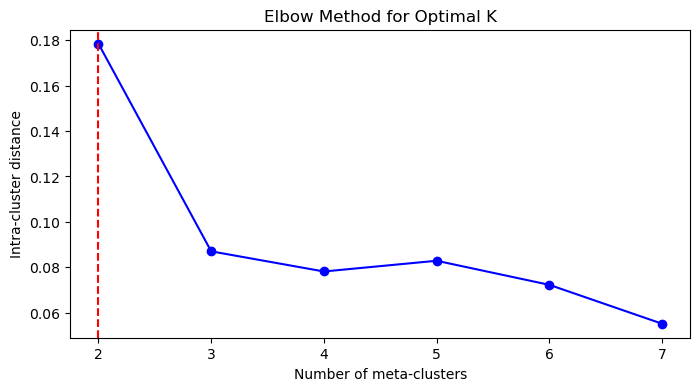

Optimal number of meta-clusters (K): 2

Adjusted Rand Index Scores:
   Cluster  ARI Score
0        0   0.419986
1        1   0.716342


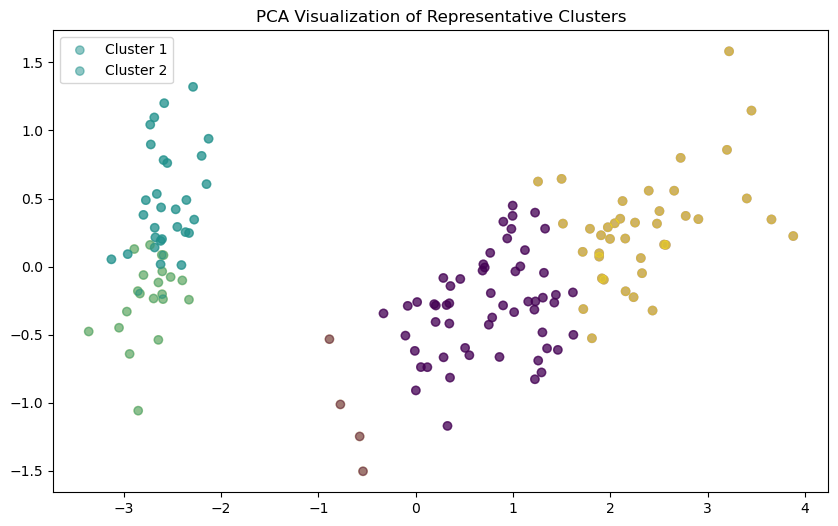

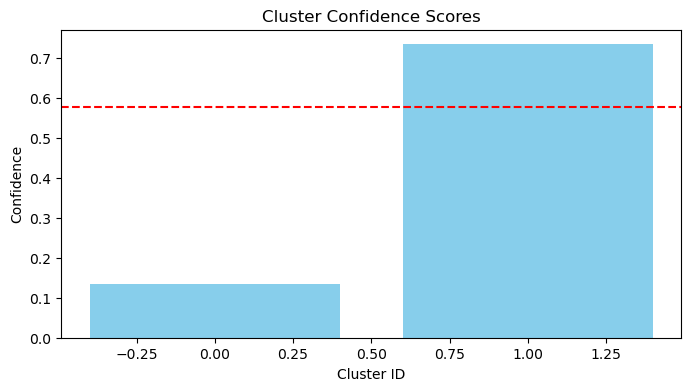

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.stats import norm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Đọc và tiền xử lý dữ liệu
df = pd.read_csv('IRIS1.csv')
features = df.iloc[:, :-1].values
true_labels = df["species"].astype("category").cat.codes.values

# 2. Tham số hệ thống
NUM_SAMPLES = 100
NOISE_LEVEL = 0.1
NUM_CLUSTERS = 3
ALPHA = 0.05
MAX_ITER = 100
MAX_META_CLUSTERS = 7  # Số cụm meta tối đa cần thử

# 3. Tạo các thế giới mẫu
def generate_samples(data, num_samples=NUM_SAMPLES, noise_level=NOISE_LEVEL):
    return [data + np.random.normal(0, noise_level, data.shape) for _ in range(num_samples)]

samples = generate_samples(features)

# 4. Phân cụm từng mẫu với K-Means++
clusterings = [KMeans(n_clusters=NUM_CLUSTERS, init='k-means++', random_state=42).fit_predict(sample) for sample in samples]

# 5. Tính ma trận khoảng cách ARI
def compute_ari_distance_matrix(clusterings):
    return np.array([[1 - adjusted_rand_score(c1, c2) for c1 in clusterings] for c2 in clusterings])

distances = compute_ari_distance_matrix(clusterings)

# 6. Hàm khởi tạo K-means++ cho K-Medoids
def kmeans_plus_plus_init(dist_matrix, n_clusters):
    n = dist_matrix.shape[0]
    medoids = []
    
    # Chọn medoid đầu tiên ngẫu nhiên
    medoids.append(np.random.choice(n))
    
    for _ in range(1, n_clusters):
        # Tính khoảng cách từ mỗi điểm đến medoid gần nhất
        distances_to_medoids = np.min(dist_matrix[:, medoids], axis=1)
        
        # Tính xác suất chọn điểm tiếp theo
        probabilities = distances_to_medoids / np.sum(distances_to_medoids)
        
        # Chọn medoid tiếp theo dựa trên xác suất
        medoids.append(np.random.choice(n, p=probabilities))
    
    return medoids

# 7. Thuật toán K-Medoids tối ưu với khởi tạo K-means++
def optimized_kmedoids(dist_matrix, n_clusters):
    n = dist_matrix.shape[0]
    
    # Khởi tạo medoids bằng K-means++
    medoids = kmeans_plus_plus_init(dist_matrix, n_clusters)
    
    for _ in range(MAX_ITER):
        labels = np.argmin(dist_matrix[:, medoids], axis=1)
        new_medoids = []
        for k in range(n_clusters):
            cluster_indices = np.where(labels == k)[0]
            if len(cluster_indices) == 0: 
                new_medoids.append(medoids[k])
                continue
            cost_matrix = dist_matrix[np.ix_(cluster_indices, cluster_indices)]
            new_medoid = cluster_indices[np.argmin(np.sum(cost_matrix, axis=1))]
            new_medoids.append(new_medoid)
        if set(new_medoids) == set(medoids): break
        medoids = new_medoids
    return medoids, labels

# 8. Phương pháp chọn K meta-clustering theo bài báo
def determine_optimal_k(dist_matrix, max_k=MAX_META_CLUSTERS):
    cluster_qualities = []
    
    for k in range(2, max_k+1):
        # Chạy K-Medoids
        medoids, labels = optimized_kmedoids(dist_matrix, k)
        
        # Tính độ đồng nhất trong cụm meta (Intra-cluster compactness)
        intra_dists = []
        for cluster_id in range(k):
            cluster_indices = np.where(labels == cluster_id)[0]
            if len(cluster_indices) > 1:
                intra_dists.append(np.mean(dist_matrix[np.ix_(cluster_indices, cluster_indices)]))
        
        # Tính chất lượng tổng hợp theo công thức (3) trong bài báo
        quality = np.mean(intra_dists) if intra_dists else np.inf
        cluster_qualities.append(quality)
    
    # Tìm điểm "khuỷu tay" (elbow point)
    deltas = np.diff(cluster_qualities)
    optimal_k = np.argmin(deltas) + 2  # +2 vì bắt đầu từ k=2
    
    # Visualize elbow curve
    plt.figure(figsize=(8,4))
    plt.plot(range(2, max_k+1), cluster_qualities, 'bo-')
    plt.xlabel('Number of meta-clusters')
    plt.ylabel('Intra-cluster distance')
    plt.title('Elbow Method for Optimal K')
    plt.axvline(x=optimal_k, color='r', linestyle='--')
    plt.show()
    
    return optimal_k

# 9. Xác định K tối ưu
optimal_k = determine_optimal_k(distances)
print(f"Optimal number of meta-clusters (K): {optimal_k}")

# 10. Chạy meta-clustering với K tối ưu
medoids, meta_labels = optimized_kmedoids(distances, optimal_k)

# 11. Tính ngưỡng τ và lọc cụm
TAU = np.percentile(distances, 95)  # Phân vị 95% của khoảng cách

def filter_representatives(clusterings, medoids, tau=TAU):
    return [c for m in medoids if np.mean(distances[m]) <= tau for c in [clusterings[m]]]

representative_clusters = filter_representatives(clusterings, medoids)

# 12. Đánh giá độ tin cậy và chất lượng
def evaluate_clusters(representatives):
    # Độ tin cậy
    confidences = []
    for m in medoids:
        cluster_size = np.sum(meta_labels == np.where(medoids == m)[0][0])
        p = cluster_size/NUM_SAMPLES
        confidences.append(p - norm.ppf(1-ALPHA)*np.sqrt(p*(1-p)/NUM_SAMPLES))
    
    # Chất lượng so với ground truth
    ari_scores = [adjusted_rand_score(true_labels, rc) for rc in representatives]
    
    return confidences, ari_scores

confidences, ari_scores = evaluate_clusters(representative_clusters)

# 13. Trực quan hóa
def visualize_results():
    # Biểu đồ PCA
    pca = PCA(n_components=2).fit_transform(samples[0])
    plt.figure(figsize=(10,6))
    for i, rc in enumerate(representative_clusters):
        plt.scatter(pca[:,0], pca[:,1], c=rc, alpha=0.5, label=f'Cluster {i+1}')
    plt.title("PCA Visualization of Representative Clusters")
    plt.legend()
    
    # Biểu đồ độ tin cậy
    plt.figure(figsize=(8,4))
    plt.bar(range(len(confidences)), confidences, color='skyblue')
    plt.axhline(TAU, color='r', linestyle='--', label=f'τ threshold ({TAU:.2f})')
    plt.title("Cluster Confidence Scores")
    plt.xlabel("Cluster ID")
    plt.ylabel("Confidence")
    
    # Kết quả ARI
    print("\nAdjusted Rand Index Scores:")
    print(pd.DataFrame({
        'Cluster': range(len(ari_scores)),
        'ARI Score': ari_scores
    }))

visualize_results()